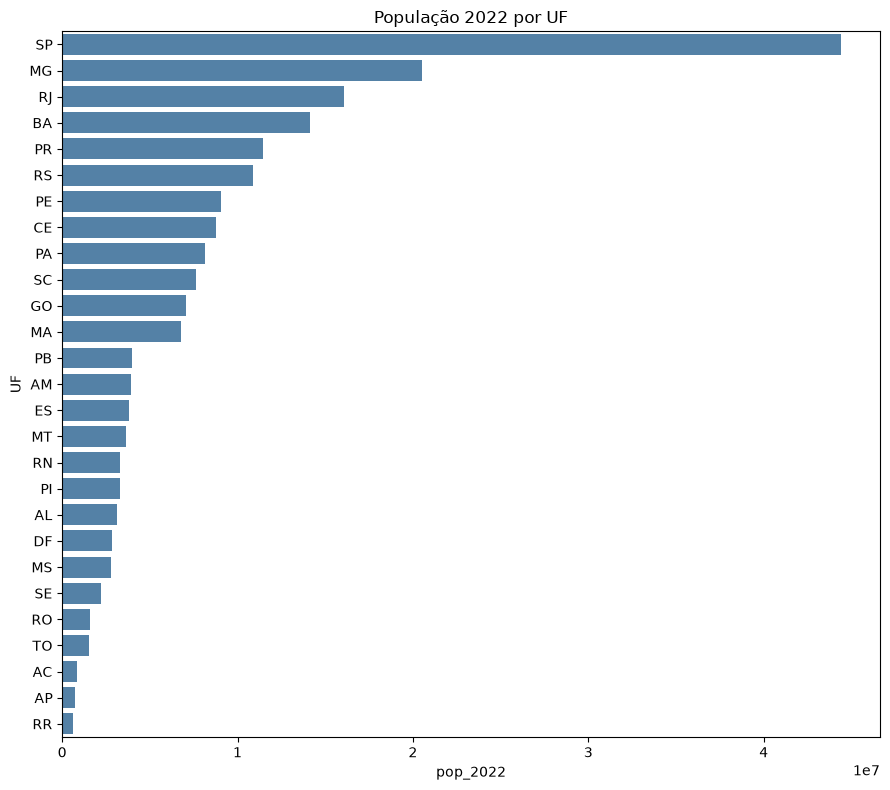

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_pop = pd.read_excel('CD2022_Populacao_2010_Compatibilizada_20231222.xlsx', header=None)
pop_clean = df_pop.iloc[3:].copy()
pop_clean.columns = ['drop', 'UF', 'cod_uf', 'cod_munic', 'nome_municipio', 'pop_2010_sinopse', 'pop_2010_compatibilizada', 'pop_2022']
pop_clean = pop_clean.drop(columns=['drop']).reset_index(drop=True)

for col in ['pop_2010_sinopse', 'pop_2010_compatibilizada', 'pop_2022']:
    pop_clean[col] = pd.to_numeric(pop_clean[col], errors='coerce')

pop_clean = pop_clean.dropna(subset=['pop_2022', 'pop_2010_compatibilizada'])

pop_estado = pop_clean.groupby('UF')[['pop_2010_sinopse', 'pop_2010_compatibilizada', 'pop_2022']].sum().reset_index()
pop_estado['crescimento'] = pop_estado['pop_2022'] - pop_estado['pop_2010_compatibilizada']
pop_estado = pop_estado.sort_values('crescimento', ascending=False).reset_index(drop=True)
pop_estado.to_csv("populacao_por_estado_crescimento.csv", sep=";", index=False, encoding="utf-8-sig")

pop_municipio = pop_clean.copy()
pop_municipio['crescimento'] = pop_municipio['pop_2022'] - pop_municipio['pop_2010_compatibilizada']
pop_municipio = pop_municipio.sort_values('crescimento', ascending=False).reset_index(drop=True)
pop_municipio.to_csv("populacao_por_municipio_crescimento.csv", sep=";", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estado.sort_values("pop_2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="pop_2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
plt.tight_layout()
plt.show()

In [2]:
!pip install pandas matplotlib seaborn xlrd openpyxl

Defaulting to user installation because normal site-packages is not writeable
